# 5 - accDM matter-power free-streaming signature

The accDM daughter is born with a velocity kick (`v ~ sqrt(eta(eta+2))/(1+eta)`), so it free-streams and **suppresses small-scale `P(k)`** - the model's observable fingerprint. This notebook checks that the suppression behaves physically:

- **A1 - shape:** `P_accDM/P_LCDM -> 1` on large scales and `< 1` on small scales (the free-streaming step).
- **A2 - scales with `f_acc`:** more accelerated DM -> deeper small-scale suppression (monotonic).
- **A3 - scales with `eta`:** a warmer daughter free-streams more -> deeper suppression **and** the cutoff moves to larger scales (smaller `k`). This is the qualitative behaviour the perturbation sector must reproduce.

Hybrid: hard asserts (nbmake/pytest) + plots. Shared massive-neutrino sector; daughter on Simpson quadrature.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

# ---- plot style ---------------------------------------------------
plt.rcParams.update({
    'mathtext.fontset': 'stix', 'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'legend.fontsize': 9, 'lines.linewidth': 1.5, 'figure.dpi': 300})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3']

K_NODES = np.logspace(-3, 0.9, 60)   # 1/Mpc

# ---- Planck 2018 base cosmology ----------------------------------
omega_b    = 0.022383
omega_cdm0 = 0.12011
A_s        = 2.1005829616811546e-9
n_s        = 0.96605
tau_reio   = 0.0543
H0         = 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}

PREC = {'output': 'mPk', 'P_k_max_1/Mpc': 10.0, 'z_max_pk': 0.0, 'evolver': 0}

A_T = 0.13; KAPPA = 2.0; MASS = 1e16; A_REC = 1.0 / (1.0 + 1090.0)

def lcdm_params():
    p = dict(base_params); p.update(PREC)
    p.update({'N_ncdm': 1, 'deg_ncdm': 3, 'm_ncdm': 0.02, 'T_ncdm': 0.71611,
              'ncdm_quadrature_strategy': 0, 'ncdm_N_momentum_bins': 15, 'N_ur': 0.00441})
    return p

def accdm_params(f_acc, eta):
    ocdm = omega_cdm0 * (1 + f_acc*(1 - A_REC**KAPPA)/(1 + (A_REC/A_T)**KAPPA))**(-1)
    p = dict(base_params); p.update(PREC)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': KAPPA, 'a_t_acc': A_T,
              'f_acc': f_acc, 'eta_acc': eta,
              'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
              'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, 2001', 'N_ur': 0.00441,
              'ncdm_fluid_approximation': 0, 'reionization_z_start_max': 80,
              'ncdm_fluid_trigger_rho_accDM_over_rho_dcdm': 1e-3, "background_Nloga": 2001})
    return p

_cache = {}
def pk_of(params, key):
    if key in _cache:
        return _cache[key]
    M = Class(); M.set(params); M.compute()
    pk = np.array([M.pk(float(k), 0.0) for k in K_NODES])
    M.struct_cleanup(); M.empty()
    _cache[key] = pk
    return pk

def ratio(f_acc, eta):
    return pk_of(accdm_params(f_acc, eta), (f_acc, eta)) / PK_LCDM

def hi_supp(r):                       # mean small-scale suppression, k > 2
    return float(1.0 - np.mean(r[K_NODES > 2.0]))

def k_cut(r):                         # k where the ratio reaches halfway to its high-k floor
    floor = np.median(r[K_NODES > 2.0])
    target = 0.5 * (1.0 + floor)
    below = np.where(r < target)[0]
    return float(K_NODES[below[0]]) if len(below) else np.inf

## LCDM reference + A1: suppression shape

In [2]:
PK_LCDM = pk_of(lcdm_params(), 'lcdm')
r_fid = ratio(0.01, 0.1)

low = float(np.mean(r_fid[K_NODES < 5e-3]))   # large-scale plateau
hi  = hi_supp(r_fid)                            # small-scale suppression
print('fiducial (f_acc=0.1, eta=0.1):  large-scale ratio = {:.4f}   small-scale suppression = {:.3f}'.format(low, hi))

assert 0.97 < low < 1.03, 'large-scale P(k) should match LCDM (ratio {:.3f})'.format(low)
assert hi > 0.02, 'no small-scale free-streaming suppression seen (got {:.3f})'.format(hi)
print('A1 PASSED (shape: flat at large k, suppressed at small k)')

fiducial (f_acc=0.1, eta=0.1):  large-scale ratio = 0.9871   small-scale suppression = 0.039
A1 PASSED (shape: flat at large k, suppressed at small k)


## A2: suppression deepens with `f_acc`

In [ ]:
F_SEQ = [1e-4, 1e-3, 1e-2, 1e-1]
supp_f = [hi_supp(ratio(f, 0.1)) for f in F_SEQ]
print('{:>8} {:>16}'.format('f_acc', 'hi-k suppression'))
for f, s in zip(F_SEQ, supp_f):
    print('{:>8.2f} {:>16.3f}'.format(f, s))
assert supp_f[0] < supp_f[1] < supp_f[2], 'small-scale suppression not monotonic in f_acc'
print('A2 PASSED (suppression grows with f_acc)')

## A3: suppression deepens and cutoff moves with `eta`

In [ ]:
E_SEQ = [1e-7, 1e-5, 1e-3, 1e-1, 1.0]
r_eta = [ratio(0.01, e) for e in E_SEQ]
supp_e = [hi_supp(r) for r in r_eta]
kcut_e = [k_cut(r) for r in r_eta]
print('{:>8} {:>16} {:>14}'.format('eta', 'hi-k suppression', 'k_cut [1/Mpc]'))
for e, s, kc in zip(E_SEQ, supp_e, kcut_e):
    print('{:>8.2f} {:>16.3f} {:>14.3e}'.format(e, s, kc))

assert supp_e[0] < supp_e[1] < supp_e[2], 'suppression not monotonic in eta (warmer should suppress more)'
assert np.all(np.isfinite(kcut_e)), 'cutoff not found - suppression too weak in range'
assert kcut_e[0] > kcut_e[1] > kcut_e[2], 'free-streaming cutoff should move to SMALLER k as eta grows'
print('A3 PASSED (warmer daughter -> deeper suppression, larger free-streaming scale)')

     eta hi-k suppression  k_cut [1/Mpc]
    0.00            0.029      1.734e+00
    0.00            0.038      2.791e-01
    0.00            0.039      2.846e-02
    0.10            0.040      2.902e-03
    1.00            0.056      1.164e-03
A3 PASSED (warmer daughter -> deeper suppression, larger free-streaming scale)


## Diagnostic plots

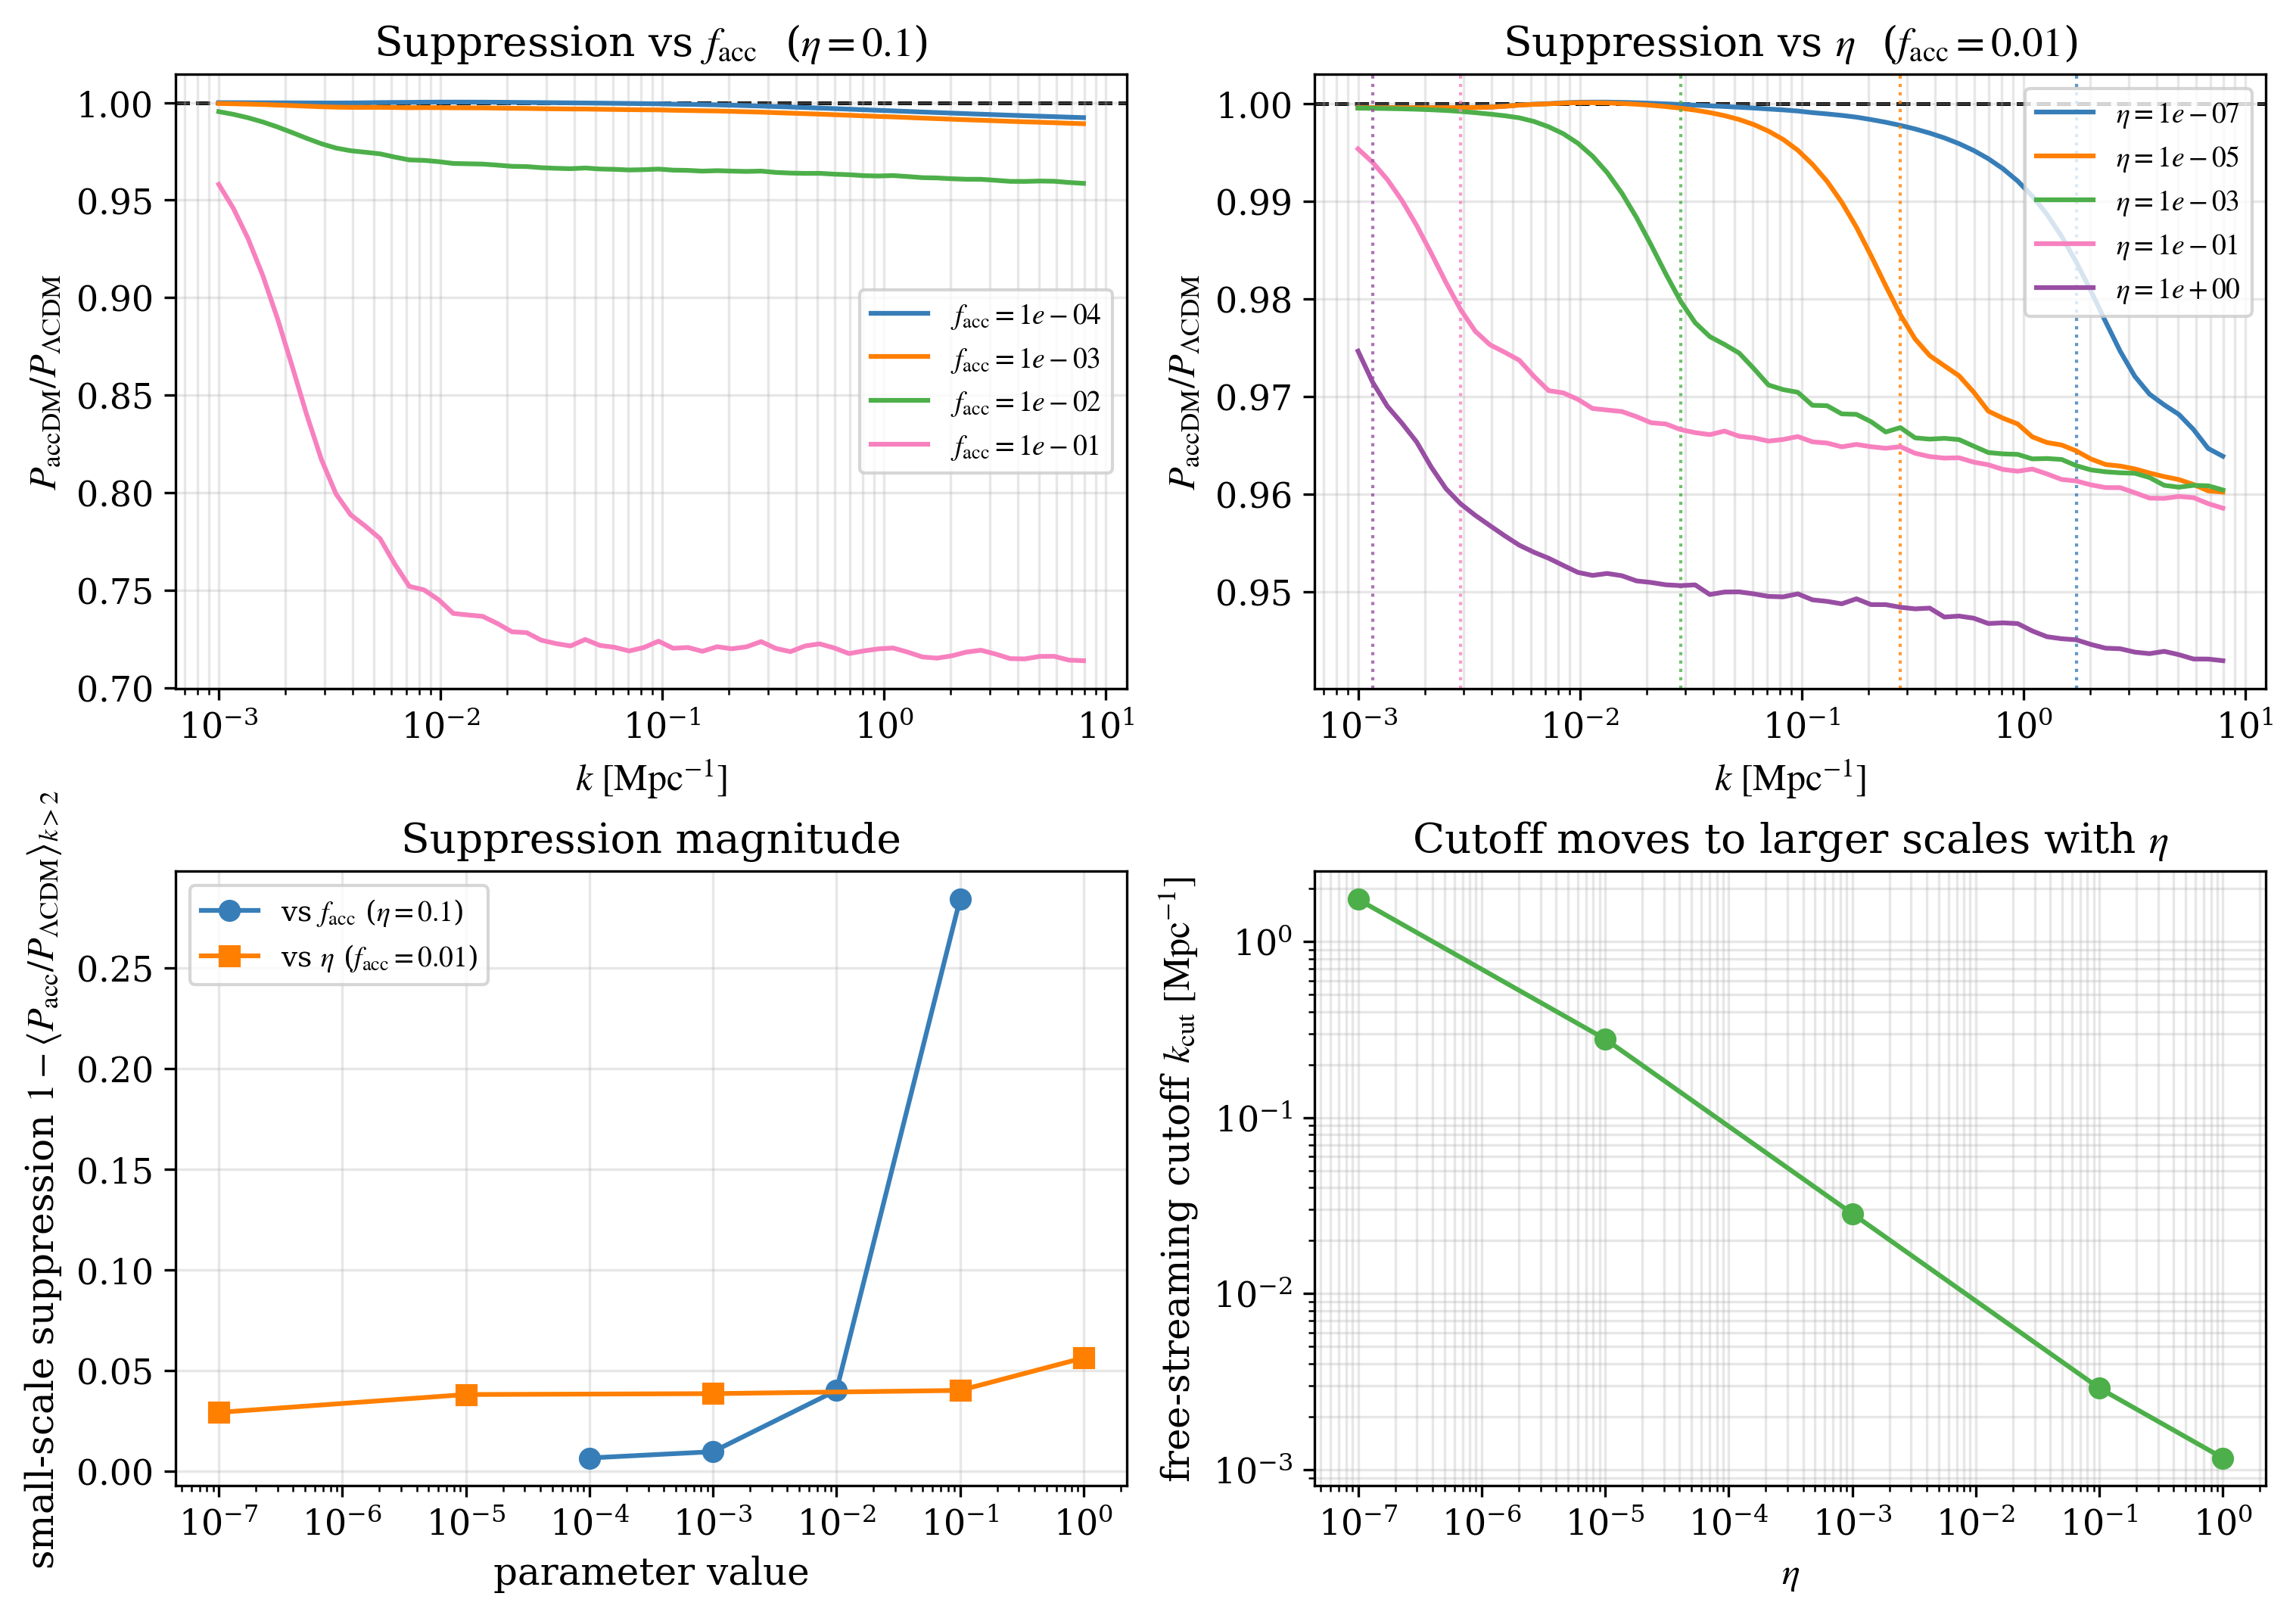

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

# (0,0) P(k) ratio across f_acc
ax = axes[0, 0]
for f, c in zip(F_SEQ, qual_colors):
    ax.semilogx(K_NODES, ratio(f, 0.1), color=c, label=r'$f_{\mathrm{acc}}=' + '{:.0e}$'.format(f))
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlabel(r'$k \ [\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\mathrm{accDM}} / P_{\Lambda\mathrm{CDM}}$')
ax.set_title(r'Suppression vs $f_{\mathrm{acc}}$  ($\eta=0.1$)')
ax.legend(loc='best'); ax.grid(True, which='both', alpha=0.3)

# (0,1) P(k) ratio across eta, with cutoff markers
ax = axes[0, 1]
for e, kc, c in zip(E_SEQ, kcut_e, qual_colors):
    ax.semilogx(K_NODES, ratio(0.01, e), color=c, label=r'$\eta=' + '{:.0e}$'.format(e))
    if np.isfinite(kc):
        ax.axvline(kc, color=c, linestyle=':', linewidth=1.0, alpha=0.8)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlabel(r'$k \ [\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\mathrm{accDM}} / P_{\Lambda\mathrm{CDM}}$')
ax.set_title(r'Suppression vs $\eta$  ($f_{\mathrm{acc}}=0.01$)')
ax.legend(loc='best'); ax.grid(True, which='both', alpha=0.3)

# (1,0) suppression magnitude vs parameter
ax = axes[1, 0]
ax.plot(F_SEQ, supp_f, 'o-', color=qual_colors[0], label=r'vs $f_{\mathrm{acc}}$ ($\eta=0.1$)')
ax.plot(E_SEQ, supp_e, 's-', color=qual_colors[1], label=r'vs $\eta$ ($f_{\mathrm{acc}}=0.01$)')
ax.set_xlabel('parameter value')
ax.set_xscale('log')

ax.set_ylabel(r'small-scale suppression $1 - \langle P_{\mathrm{acc}}/P_{\Lambda\mathrm{CDM}}\rangle_{k>2}$')
ax.set_title('Suppression magnitude'); ax.legend(loc='best'); ax.grid(True, alpha=0.3)

# (1,1) cutoff scale vs eta
ax = axes[1, 1]
ax.semilogy(E_SEQ, kcut_e, 'o-', color=qual_colors[2])
ax.set_xlabel(r'$\eta$')
ax.set_xscale('log')

ax.set_ylabel(r'free-streaming cutoff $k_{\mathrm{cut}} \ [\mathrm{Mpc}^{-1}]$')
ax.set_title(r'Cutoff moves to larger scales with $\eta$'); ax.grid(True, which='both', alpha=0.3)

plt.show()

### Notes
- The free-streaming velocity `v ~ sqrt(eta(eta+2))/(1+eta)` is set by `eta`, not the mass, so even the very heavy (`1e16 GeV`) daughter free-streams and leaves a `P(k)` step in the observable range.
- Asserts are **qualitative/monotonic** (suppression grows with `f_acc` and `eta`; cutoff moves to smaller `k` with `eta`) rather than fixed magnitudes - the exact suppression depends on the q-grid and the daughter sound speed. Bump `ncdm_N_momentum_bins` (daughter) from 201 for tighter shapes.
- The code's own diagnostic `k_fss_acc` (`perturbations.c`, evaluated at `a_t`) is the analytic counterpart of the measured `k_cut`; a future refinement could assert they agree to order unity if `k_fss_acc` is exposed in the output.
- pytest/nbmake: `pytest --nbmake notebooks_test/5_test_Pk_freestreaming.ipynb`.